In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("study.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


In [3]:
df.head()

,study_hours,grade
0,3.745401,30.203939
1,9.507143,57.878452
2,7.319939,46.368401
3,5.986585,39.330717
4,1.560186,14.843888


In [4]:
y = torch.tensor(df['grade'].values)
X = torch.tensor(df['study_hours'].values)

In [5]:
X

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015, 1.2204, 4.9518, 0.3439, 9.0932, 2.5878,
        6.6252, 3.1171, 5.2007, 5.4671, 1.8485], dtype=torch.float64)

In [6]:
y

tensor([30.2039, 57.8785, 46.3684, 39.3307, 14.8439, 16.3600, 11.9829, 55.4231,
        40.7430, 41.8775, 11.6774, 57.7253, 50.2683, 21.8403, 21.1532, 21.0328,
        23.5337, 35.6194, 32.2598, 26.5125, 39.6343, 16.6034, 22.3946, 25.9257,
        34.4286, 51.9713, 19.8397, 37.7188, 40.3440, 11.0323, 41.1000, 21.6023,
        13.1809, 60.5736, 53.0421, 52.0637, 25.4048, 14.2856, 44.3952, 28.0325,
        15.6626, 35.4731, 14.6752, 54.4295, 21.3220, 42.1226, 27.4164, 36.6609,
        36.2760, 20.2693], dtype=torch.float64)

In [7]:
# train - test split

In [8]:
train_split = int(len(X) * 0.8)
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

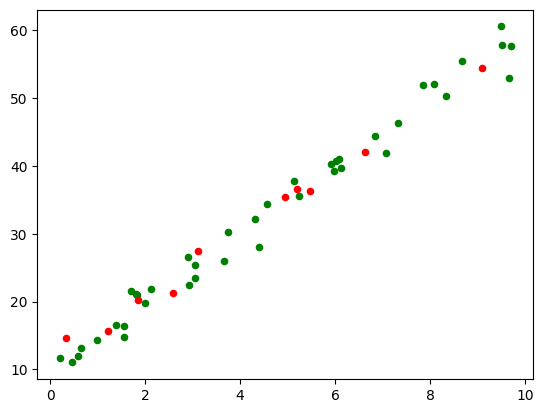

In [9]:
plt.scatter(X_train, y_train, c="green", s=20, label='Train Data')
plt.scatter(X_test, y_test, c="red", s=20, label='Test Data')

In [10]:
from torch import nn

In [11]:
class SimpleLinearRegressinModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)
        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weight * x + self.bias

In [12]:
'''
class SimpleLinearRegressinModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(in_features=1, out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)
'''

'\nclass SimpleLinearRegressinModel(nn.Module):\n    def __init__(self):\n        super().__init__()\n        self.linear = nn.Linear(in_features=1, out_features=1)\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        return self.linear(x)\n'

In [42]:
torch.manual_seed(42)
model_0 = SimpleLinearRegressinModel()
model_0 = torch.compile(model_0)

In [43]:
model_0.state_dict()

OrderedDict([('_orig_mod.weight', tensor([0.3367])),
             ('_orig_mod.bias', tensor([0.1288]))])

In [44]:
with torch.inference_mode():
    y_pred = model_0(X_test)

y_pred

tensor([0.5397, 1.7960, 0.2446, 3.1904, 1.0001, 2.3595, 1.1783, 1.8798, 1.9695,
        0.7512], dtype=torch.float64)

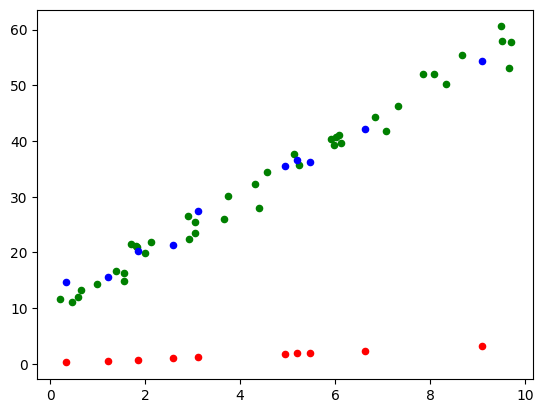

In [45]:
plt.scatter(X_train, y_train, c="green", s=20, label='Train Data')
plt.scatter(X_test, y_test, c="blue", s=20, label='Test Data')
plt.scatter(X_test, y_pred, c="red", s=20, label='Predicted Data')

In [46]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.001)

In [47]:
torch.manual_seed(42)

epochs = 120
train_loss_values = []
test_loss_values = []
epoch_count = []


for epoch in range(epochs):
    model_0.train()

    y_pred = model_0(X_train)

    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()  ## önceki adımdan kalan gradyan(türevleri) sıfırlanır
    loss.backward()        ## parametrelere göre gradyanları(türevleri) hesaplar
    optimizer.step()       ## modelin gradientlerini kullanarak parametrelerini günceller

    model_0.eval()

    with torch.inference_mode():
        test_pred = model_0(X_test)
        test_loss = loss_fn(test_pred, y_test)

        if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().item())
            test_loss_values.append(test_loss.detach().item())
            print(f"Epoch: {epoch} | Train Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f}")


Epoch: 0 | Train Loss: 1156.0767 | Test Loss: 858.3089
Epoch: 10 | Train Loss: 352.9913 | Test Loss: 280.9052
Epoch: 20 | Train Loss: 120.4127 | Test Loss: 108.9803
Epoch: 30 | Train Loss: 52.9314 | Test Loss: 56.5503
Epoch: 40 | Train Loss: 33.2285 | Test Loss: 39.8529
Epoch: 50 | Train Loss: 27.3538 | Test Loss: 34.1127
Epoch: 60 | Train Loss: 25.4828 | Test Loss: 31.8736
Epoch: 70 | Train Loss: 24.7722 | Test Loss: 30.8253
Epoch: 80 | Train Loss: 24.3994 | Test Loss: 30.2173
Epoch: 90 | Train Loss: 24.1262 | Test Loss: 29.7888
Epoch: 100 | Train Loss: 23.8837 | Test Loss: 29.4411
Epoch: 110 | Train Loss: 23.6519 | Test Loss: 29.1330


Text(0.5, 1.0, 'Train and Test Loss over Epochs')

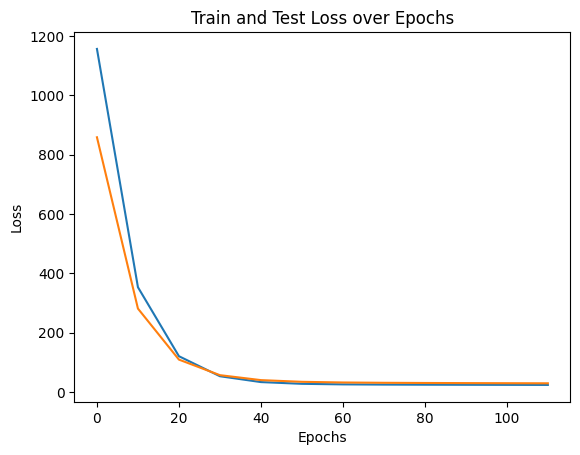

In [48]:
plt.plot(epoch_count, train_loss_values, label='Train Loss')
plt.plot(epoch_count, test_loss_values, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train and Test Loss over Epochs')

In [49]:
model_0.state_dict()

OrderedDict([('_orig_mod.weight', tensor([6.2983])),
             ('_orig_mod.bias', tensor([1.6607]))])

In [51]:
model_0.eval()
with torch.inference_mode():
    y_preds = model_0(X_test)

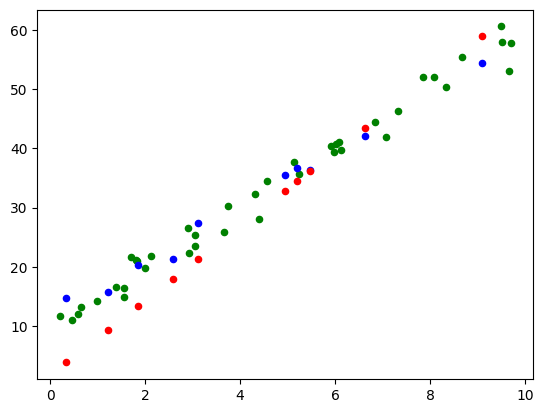

In [52]:
plt.scatter(X_train, y_train, c="green", s=20, label='Train Data')
plt.scatter(X_test, y_test, c="blue", s=20, label='Test Data')
plt.scatter(X_test, y_preds, c="red", s=20, label='Predicted Data')